In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

# Problem 1: Z-Score Method (Normal Data)

In [15]:
students_age = np.array([18, 19, 20, 20, 21, 21, 22, 22, 23, 24, 25, 26, 27, 28, 30, 32, 35, 40, 45, 70])

mean_of_age = students_age.mean()
SD_of_age = students_age.std()

zscore = (students_age - mean_of_age) / SD_of_age

outliers_age = students_age[abs(zscore) > 3]

clean_data = students_age[abs(zscore) <= 3]

print(f"Mean of age: {mean_of_age}")
print(f"Standard deviation of age: {SD_of_age}")
print(f"Z-score of age: {zscore}")
print(f"Outliers: {outliers_age}")
print(f"Outlier count: {len(outliers_age)}")         
print(f"Clean data length: {len(clean_data)}")         
print(f"Clean data: {clean_data}")

Mean of age: 28.4
Standard deviation of age: 11.825396399275586
Z-score of age: [-0.87946312 -0.79489936 -0.7103356  -0.7103356  -0.62577183 -0.62577183
 -0.54120807 -0.54120807 -0.45664431 -0.37208055 -0.28751679 -0.20295303
 -0.11838927 -0.0338255   0.13530202  0.30442954  0.55812083  0.98093963
  1.40375844  3.51785248]
Outliers: [70]
Outlier count: 1
Clean data length: 19
Clean data: [18 19 20 20 21 21 22 22 23 24 25 26 27 28 30 32 35 40 45]


# Problem 2: IQR Method (Skewed Data)

In [29]:
salary = np.array([25, 28, 30, 32, 32, 33, 35, 35, 36, 38, 40, 42, 45, 48, 50, 55, 60, 65, 70, 80, 120, 150, 200, 250, 500])
salary = pd.Series(salary)

Q1 = salary.quantile(0.25)
Q3 = salary.quantile(0.75)

IQR = Q3 - Q1

lower_bound = max(0, Q1 - 1.5 * IQR)
upper_bound = Q3 + 1.5 * IQR

# Identify outliers.
outlier_IQR = (salary < lower_bound) | (salary > upper_bound)

# cap
salary_capped = salary.clip(lower_bound, upper_bound)

# Show min and max after capping.
salary_min = salary_capped.min()
salary_max = salary_capped.max()

print(f"IQR: {IQR}")
print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")
print(f"Identify outliers: {salary[outlier_IQR]}")
print(f"Outlier count:    {outlier_IQR.sum()}")
print(f"Min after capping: {salary_min}")
print(f"Max after capping: {salary_max}")

IQR: 35.0
Lower Bound: 0
Upper Bound: 122.5
Identify outliers: 21    150
22    200
23    250
24    500
dtype: int64
Outlier count:    4
Min after capping: 25.0
Max after capping: 122.5


# Problem 3: Choose the Right Method

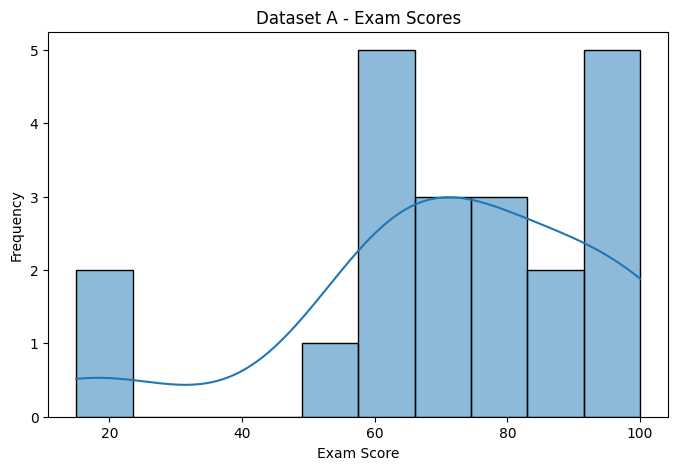

Dataset A:
The distribution is skewed because of extreme low scores (15, 20).
So, IQR method is better than Z-Score.

Dataset B:
House price data is highly right-skewed.
So, IQR method is better for detecting outliers.

Q1: 45.0
Q3: 200.0
IQR: 155.0
Lower Bound: -187.5
Upper Bound: 432.5

Outliers:
[500, 800, 1000, 1200]

Total Outliers: 4


In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

exam_score = np.array([55, 58, 60, 62, 65, 65, 68, 70, 72, 75, 78, 80, 85, 90, 95, 98, 100, 100, 100, 15, 20])

house_price = np.array([30, 32, 35, 38, 40, 42, 45, 48, 50, 55, 60, 65, 70, 80, 90, 100, 120, 150, 200, 300, 400, 500, 800, 1000, 1200])

exam_score = pd.Series(exam_score)
house_price = pd.Series(house_price)

plt.figure(figsize=(8, 5))

sns.histplot(exam_score, bins=10, kde=True)
plt.title("Dataset A - Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Frequency")
plt.show()

print("Dataset A:")
print("The distribution is skewed because of extreme low scores (15, 20).")
print("So, IQR method is better than Z-Score.")
print()

# -----------------------------------
# Method selection for Dataset B
# -----------------------------------
print("Dataset B:")
print("House price data is highly right-skewed.")
print("So, IQR method is better for detecting outliers.")
print()


# Apply IQR on Dataset B and count how many outliers you get
Q1 = house_price.quantile(0.25)
Q3 = house_price.quantile(0.75)

IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = house_price[
    (house_price < lower_bound) | (house_price > upper_bound)
]

print(f"Q1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")

print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")

print("\nOutliers:")
print(outliers.tolist())

print(f"\nTotal Outliers: {len(outliers)}")

# Problem 4: Winsorization (Percentile Method)

In [41]:
product_rating = np.array([1, 2, 3, 4, 4, 5, 5, 5, 6, 6, 7, 7, 8, 8, 9, 9, 10, 10, 1, 2, 10, 10, 10, 0.5, 9.5])
product_rating = pd.Series(product_rating)

# Winsorization percentage
x = 5
x = x/100

min_range = product_rating.quantile(x)
max_range = product_rating.quantile(1 - x)

product_rating_winsorized = product_rating.clip(min_range, max_range)

min_after = product_rating_winsorized.min()
max_after = product_rating_winsorized.max()

print(f"5th Percentile: {min_range}")
print(f"95th Percentile: {max_range}")

print("\nOriginal Data:")
print(product_rating.tolist())

print("\nWinsorized Data:")
print(product_rating_winsorized.tolist())

print(f"\nMin after Winsorization: {min_after}")
print(f"Max after Winsorization: {max_after}")

print("\nExplanation:")
print("Winsorization is better than deletion here because it keeps all data points.")
print("Instead of removing extreme values, it caps them to a reasonable range.")
print("This helps reduce the effect of outliers while preserving dataset size.")

5th Percentile: 1.0
95th Percentile: 10.0

Original Data:
[1.0, 2.0, 3.0, 4.0, 4.0, 5.0, 5.0, 5.0, 6.0, 6.0, 7.0, 7.0, 8.0, 8.0, 9.0, 9.0, 10.0, 10.0, 1.0, 2.0, 10.0, 10.0, 10.0, 0.5, 9.5]

Winsorized Data:
[1.0, 2.0, 3.0, 4.0, 4.0, 5.0, 5.0, 5.0, 6.0, 6.0, 7.0, 7.0, 8.0, 8.0, 9.0, 9.0, 10.0, 10.0, 1.0, 2.0, 10.0, 10.0, 10.0, 1.0, 9.5]

Min after Winsorization: 1.0
Max after Winsorization: 10.0

Explanation:
Winsorization is better than deletion here because it keeps all data points.
Instead of removing extreme values, it caps them to a reasonable range.
This helps reduce the effect of outliers while preserving dataset size.
